In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from natsort import natsorted
import seaborn as sns
# -----------------------------
# 1) Enter your summary numbers
# -----------------------------
strategies = ["early", "late_avg", "late_stack", "mask_token"]



In [13]:
def parse_auc_table(df):
    """
    Convert a dataframe with columns:
    Strategy | AUC (mean±sd)
    into two lists: mean, sd
    """
    means = []
    sds = []

    for val in df["AUC"]:
        mean_str, sd_str = val.split("±")
        means.append(float(mean_str))
        sds.append(float(sd_str))

    return means, sds

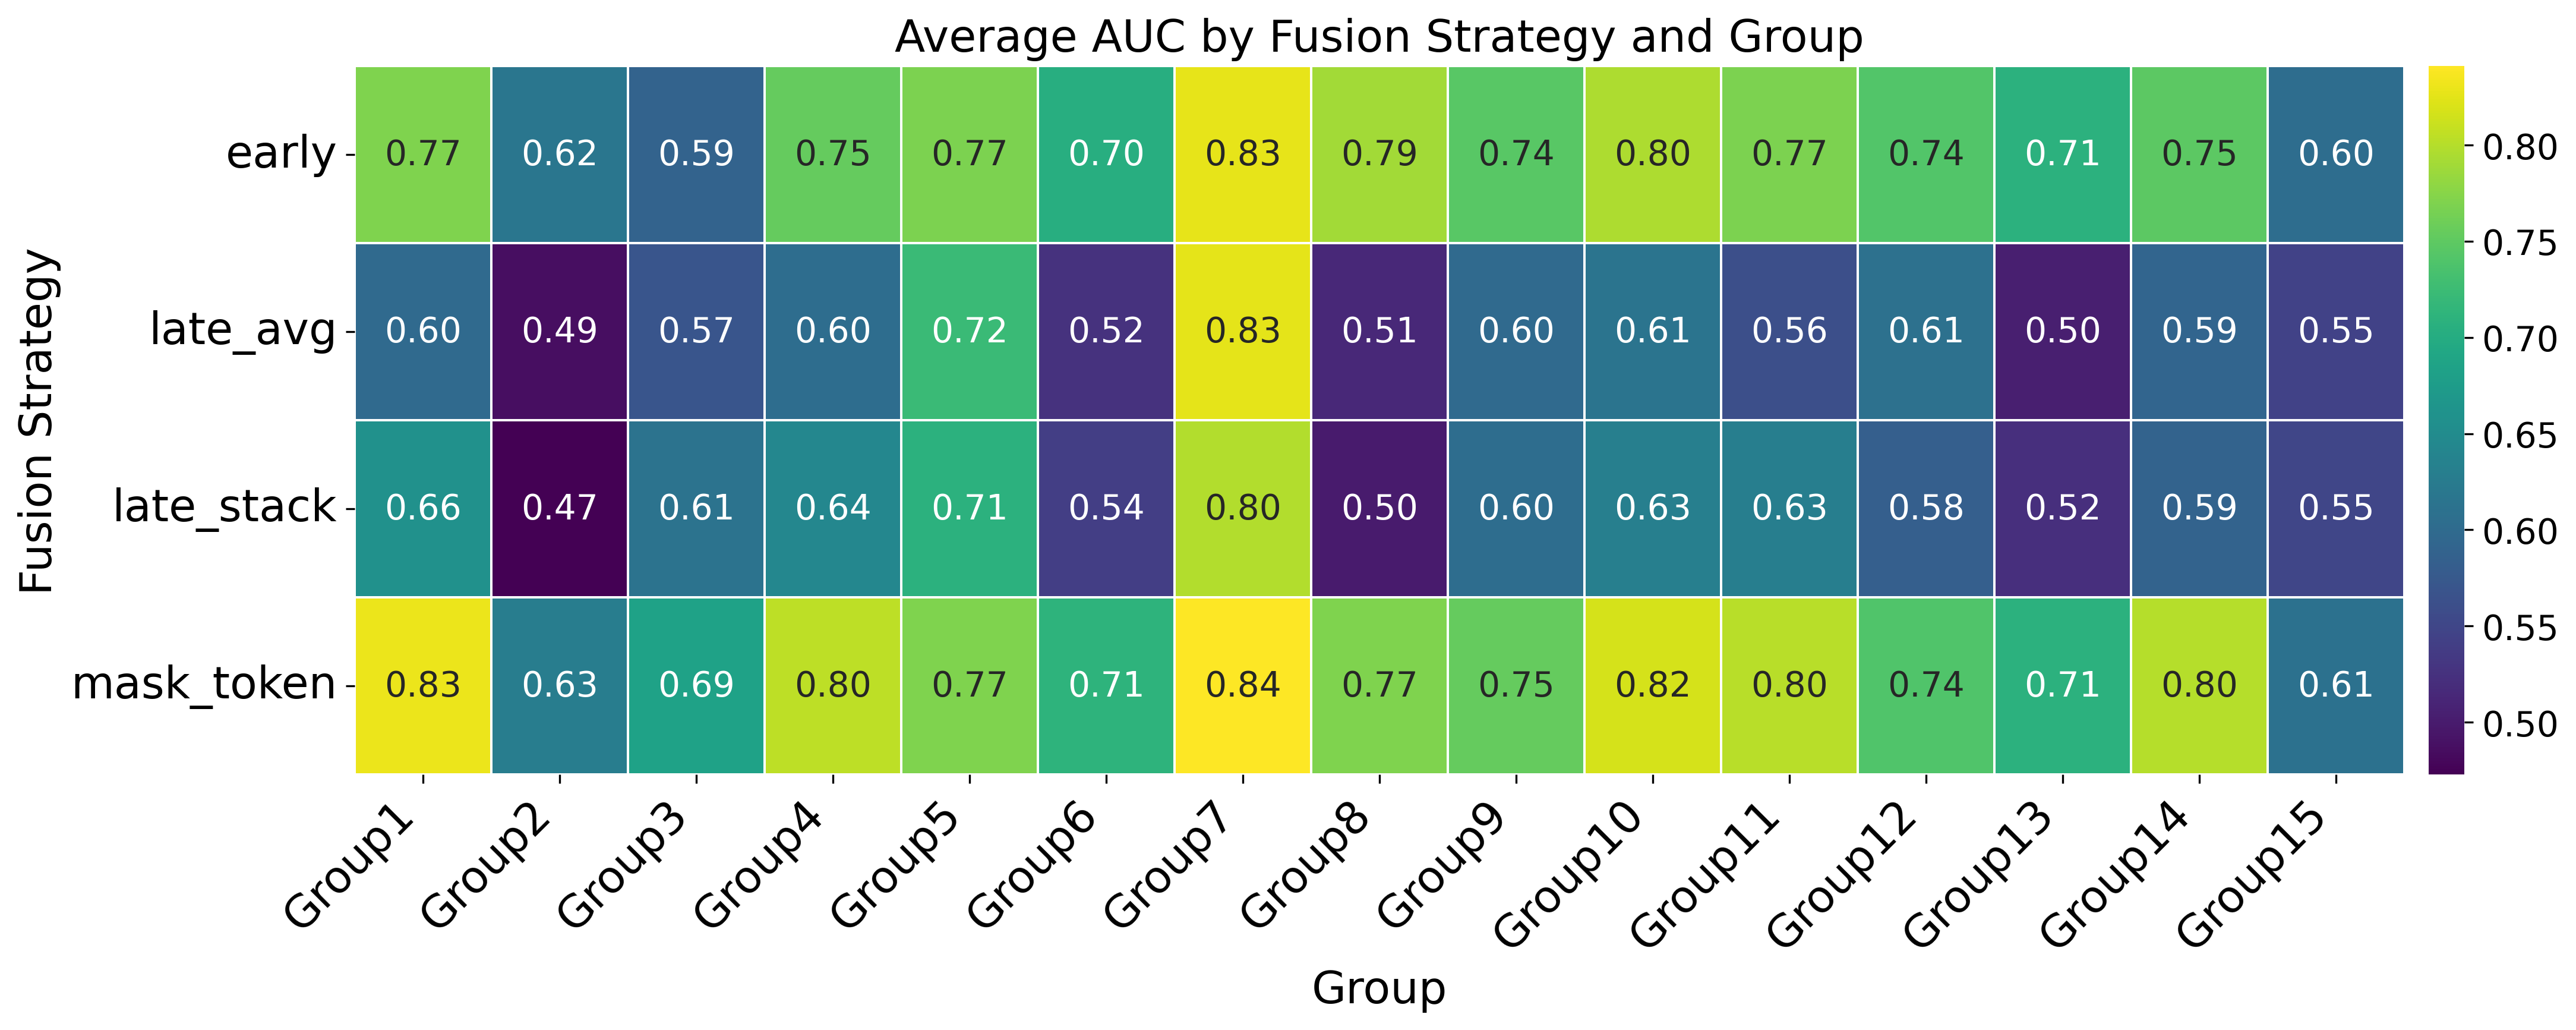

In [ ]:
from config import DATA_ROOT_DIR
data_root_dir = os.path.join(DATA_ROOT_DIR, "output/fusion_strategy_eval_groupwise")

strategies = ["early", "late_avg", "late_stack", "mask_token"]

groups = [f"Group{i}" for i in range(1, 16)]

eval_df_all_groups = {"strategy": [], "group": [], "mean_auc": [], "std_auc": []}

for g in groups:
    data_fn = os.path.join(data_root_dir, f"{g}_groupwise_comparison_results.csv")
    df = pd.read_csv(data_fn)
    means, sds = parse_auc_table(df)
    for s, mean, sd in zip(strategies, means, sds):
        eval_df_all_groups["strategy"].append(s)
        eval_df_all_groups["group"].append(g)
        eval_df_all_groups["mean_auc"].append(mean)
        eval_df_all_groups["std_auc"].append(sd)

eval_df_all_groups = pd.DataFrame(eval_df_all_groups)
heatmap_data = eval_df_all_groups.pivot(index="strategy", columns="group", values="mean_auc")
# Sort columns naturally
heatmap_data = heatmap_data[natsorted(heatmap_data.columns)]

# Plot heatmap
plt.rcParams.update({'font.size': 14})  
plt.figure(figsize=(16, 6), dpi=300)
sns.heatmap(
    heatmap_data,
    annot=True,          # show values
    fmt=".2f",           # format AUC
    cmap="viridis",      # color map
    linewidths=0.5,
    # vmin=0.0,   # minimum color scale
    # vmax=0.9,   # maximum color scale
    cbar_kws={
        "pad": 0.01   # ↓ reduce this value (default ≈ 0.05)
    }
)

plt.title("Average AUC by Fusion Strategy and Group", fontsize=18)
plt.xlabel("Group", fontsize=18)
plt.xticks(rotation=45, ha="right", fontsize=18)
plt.ylabel("Fusion Strategy", fontsize=18)
plt.yticks(rotation=0, fontsize=18)
plt.tight_layout()
plt.show()


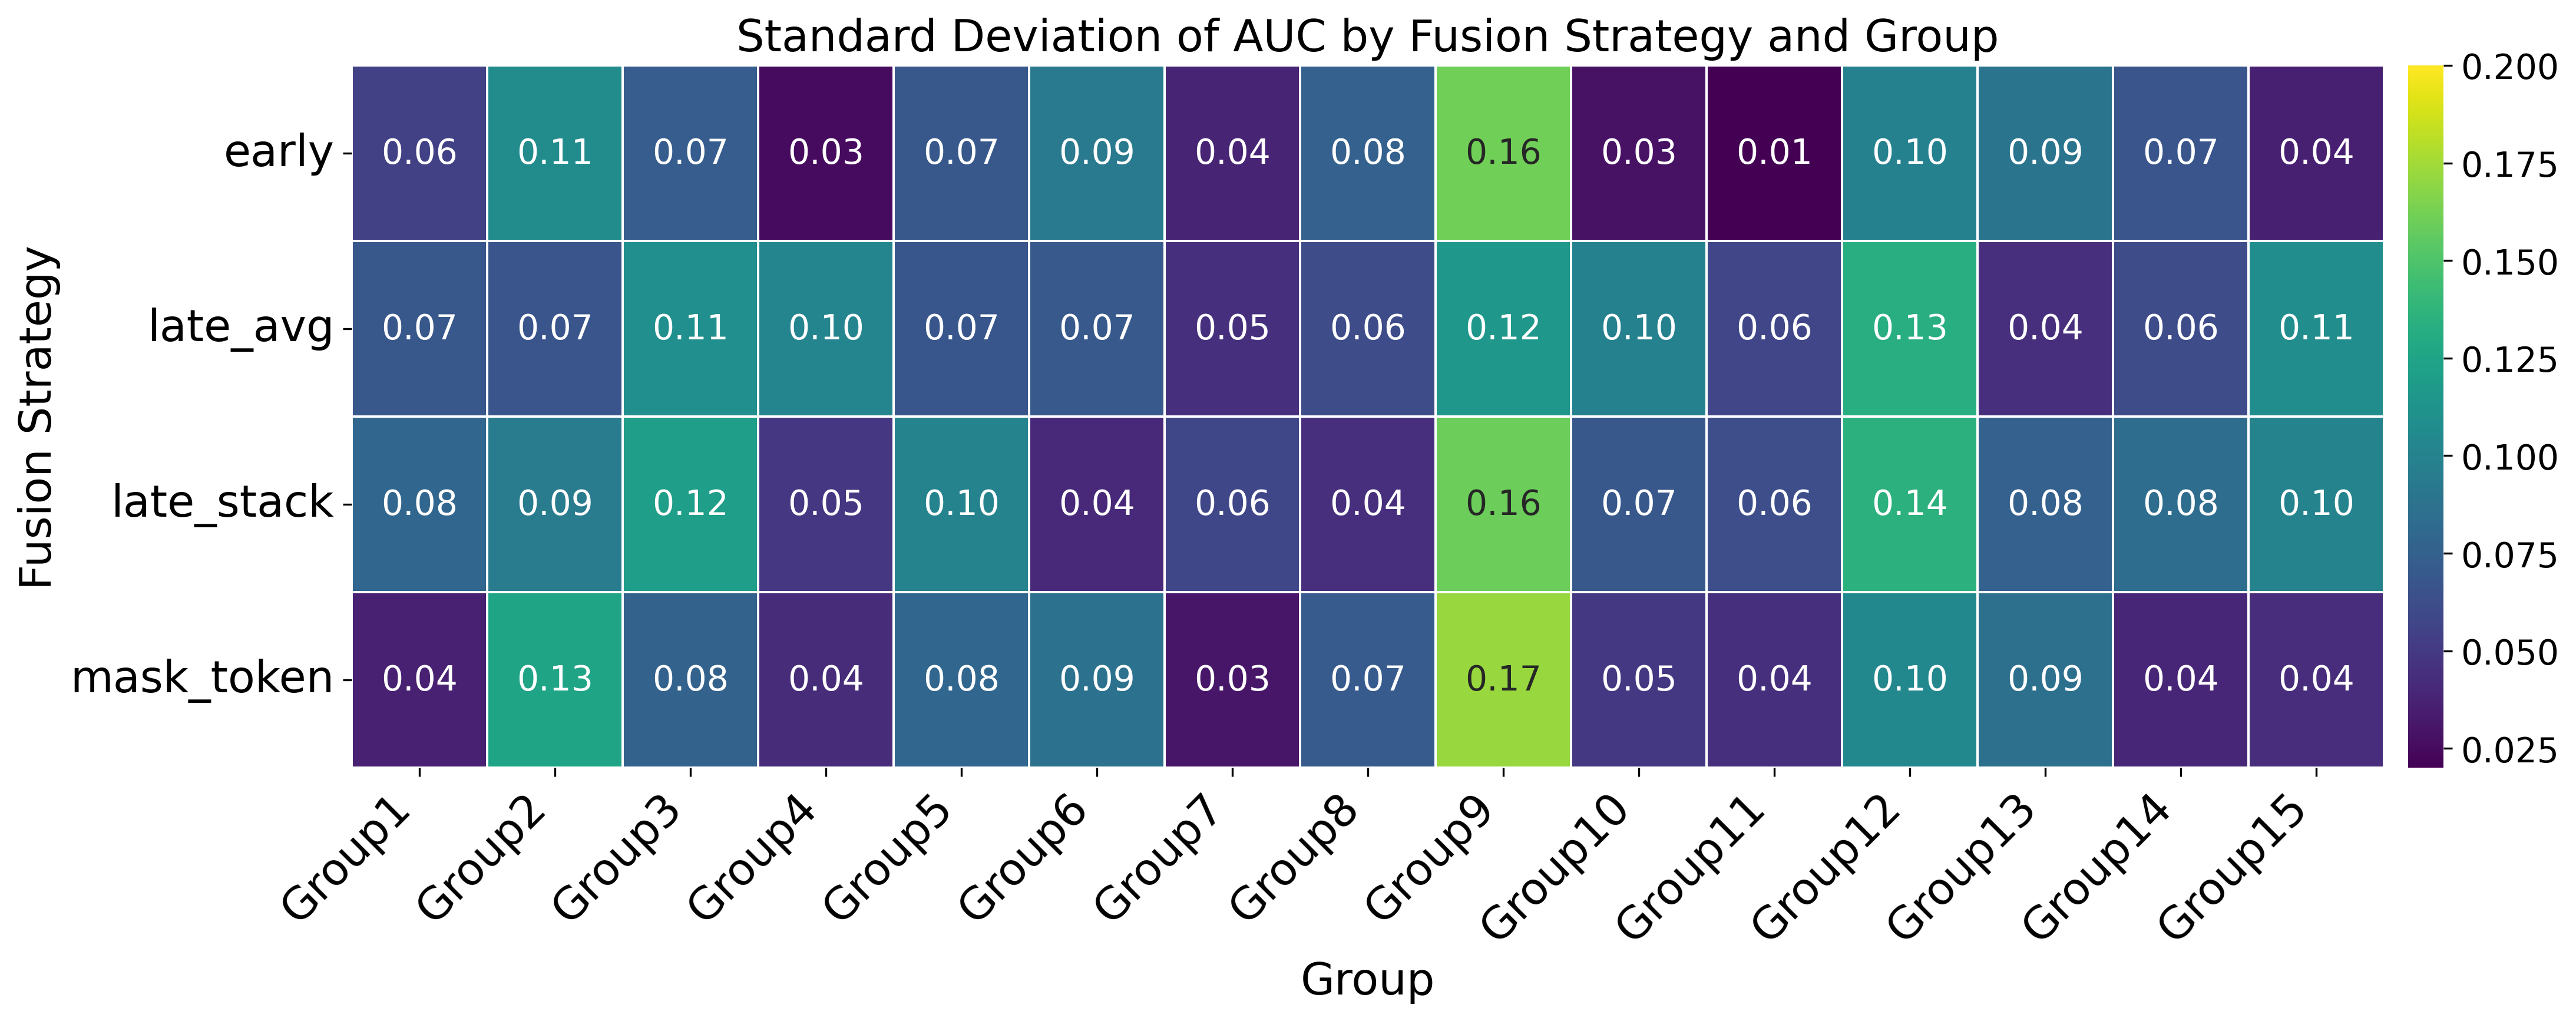

In [18]:
heatmap_data = eval_df_all_groups.pivot(index="strategy", columns="group", values="std_auc")
# Sort columns naturally
heatmap_data = heatmap_data[natsorted(heatmap_data.columns)]

# Plot heatmap
plt.rcParams.update({'font.size': 14})  
plt.figure(figsize=(16, 6), dpi=300)
sns.heatmap(
    heatmap_data,
    annot=True,          # show values
    fmt=".2f",           # format AUC
    cmap="viridis",      # color map
    linewidths=0.5,
    vmin=0.02,   # minimum color scale
    vmax=0.20,   # maximum color scale
    cbar_kws={
        "pad": 0.01   # ↓ reduce this value (default ≈ 0.05)
    }
)

plt.title("Standard Deviation of AUC by Fusion Strategy and Group", fontsize=18)
plt.xlabel("Group", fontsize=18)
plt.xticks(rotation=45, ha="right", fontsize=18)
plt.ylabel("Fusion Strategy", fontsize=18)
plt.yticks(rotation=0, fontsize=18)
plt.tight_layout()
plt.show()
